# shap — Standard SHAP Baseline

The `shap` library is the de facto standard for Shapley-based explainability, providing KernelSHAP, PermutationSHAP, and tree-specific exact methods. This notebook establishes `shap` as the primary marginal baseline in the ShapiqBench comparison, evaluating Shapley value quality and runtime against `shapiq` on both the Adult and Superconductivity datasets. Pairwise interaction support (trees only) is assessed where applicable.

In [4]:
from Models.load_and_train import TrainingConfig
# First load and train the models on different datasets
all_combi_configs = TrainingConfig.get_all_configs(pytorch=False)
all_trained_models = [config.train(verbose=True) for config in all_combi_configs]

print("All models trained successfully!")
print(f"Total number of trained models: {len(all_trained_models)}")

Trained random_forest_regressor on california_housing
Trained random_forest_regressor on ames_housing
Trained random_forest_regressor on covertype
All models trained successfully!
Total number of trained models: 3


## Time-Agnostic Evaluation

For each dataset × model combination we run two explainers and record wall-clock time:

| Method | Type | Notes |
|---|---|---|
| **KernelSHAP** | Approximation (model-agnostic) | Fits a weighted linear model around each prediction; slow but universal |
| **TreeSHAP** | True Value (tree-specific) | Exact Shapley values via `shap.Explainer`; auto-selects the tree algorithm, traversing decision paths in polynomial time |

100 background samples are used as the KernelSHAP reference distribution; explanations are computed for 20 held-out samples. A runtime bar chart is shown per combination, followed by a waterfall plot for the first sample from each method.


=== California Housing | random_forest_regressor ===
  KernelSHAP ...
  TreeSHAP (true value) ...
  KernelSHAP: 4.793s | TreeSHAP: 4.713s | Speedup: 1.0x


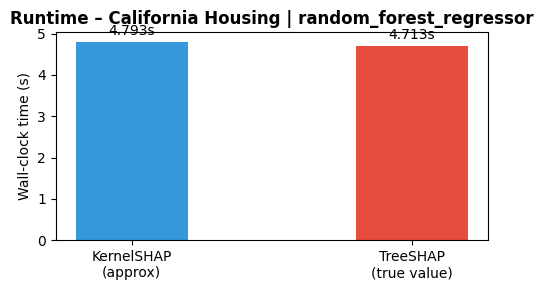

  KernelSHAP waterfall – California Housing (sample 0):


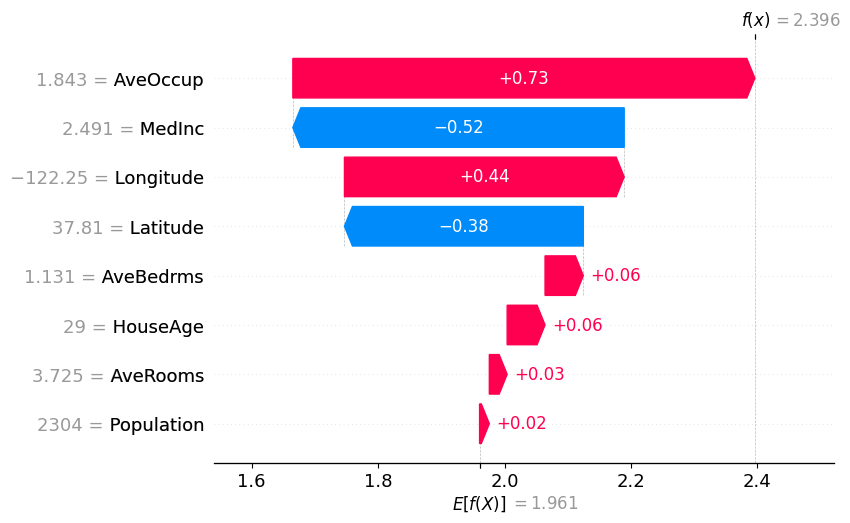

  TreeSHAP waterfall – California Housing (sample 0):


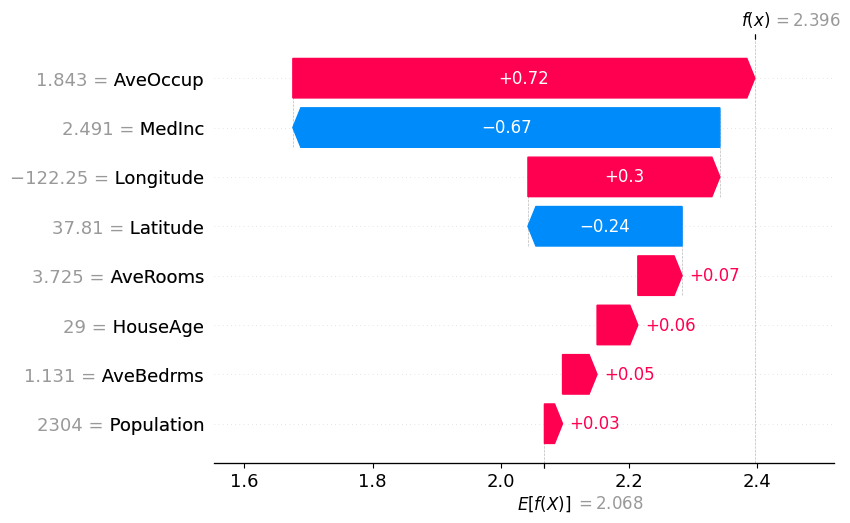


=== Ames Housing | random_forest_regressor ===
  KernelSHAP ...
  TreeSHAP (true value) ...
  KernelSHAP: 19.379s | TreeSHAP: 0.599s | Speedup: 32.4x


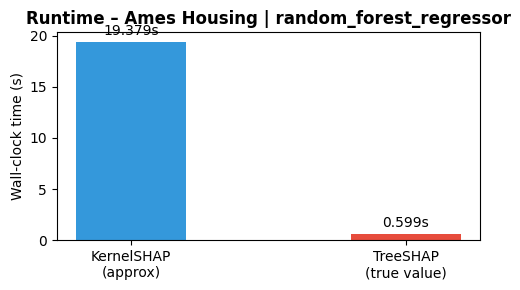

  KernelSHAP waterfall – Ames Housing (sample 0):


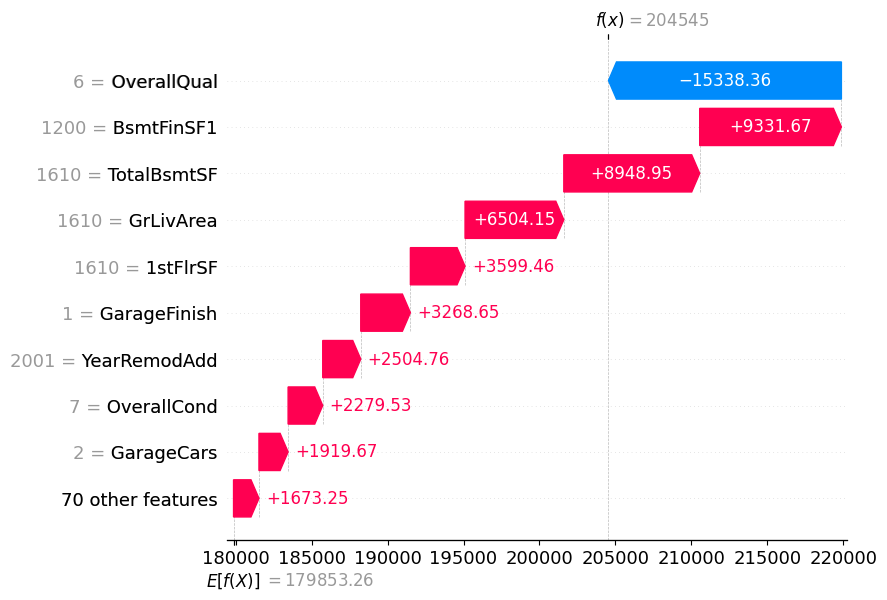

  TreeSHAP waterfall – Ames Housing (sample 0):


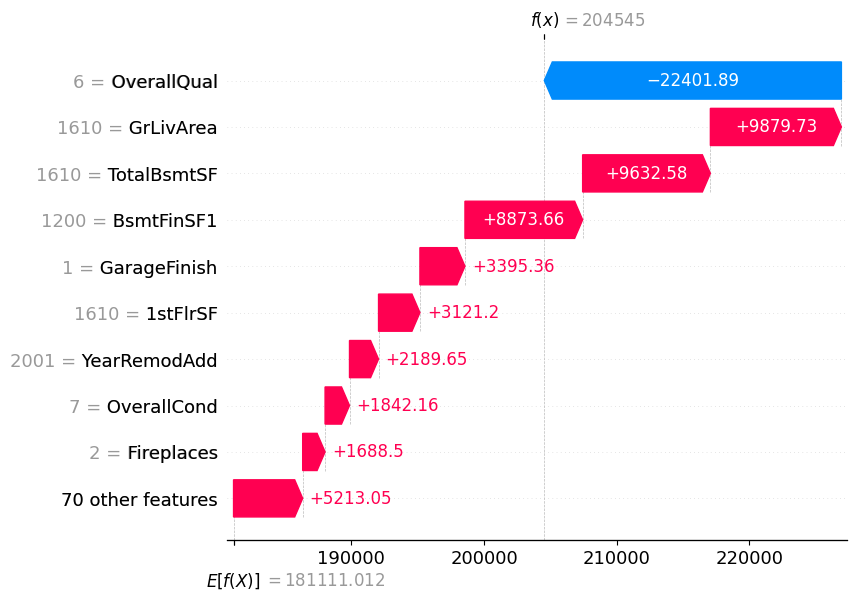


=== Forest Covertype | random_forest_regressor ===
  KernelSHAP ...
  TreeSHAP (true value) ...
  KernelSHAP: 23.334s | TreeSHAP: 3.331s | Speedup: 7.0x


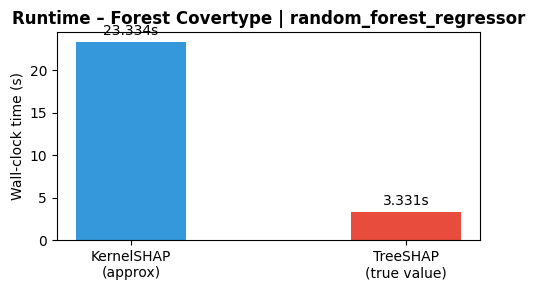

  KernelSHAP waterfall – Forest Covertype (sample 0):


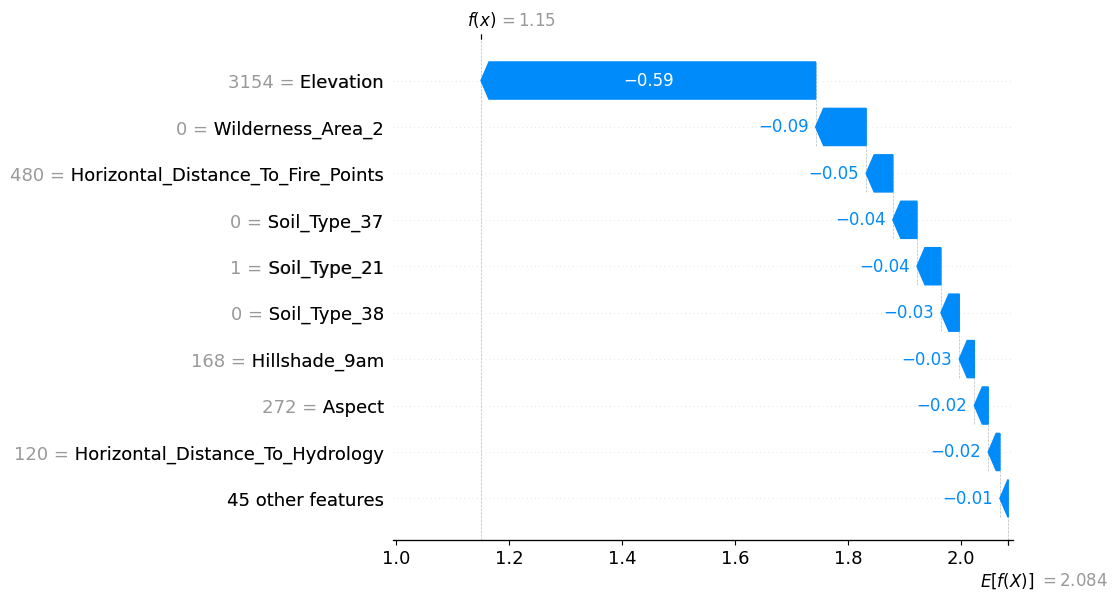

  TreeSHAP waterfall – Forest Covertype (sample 0):


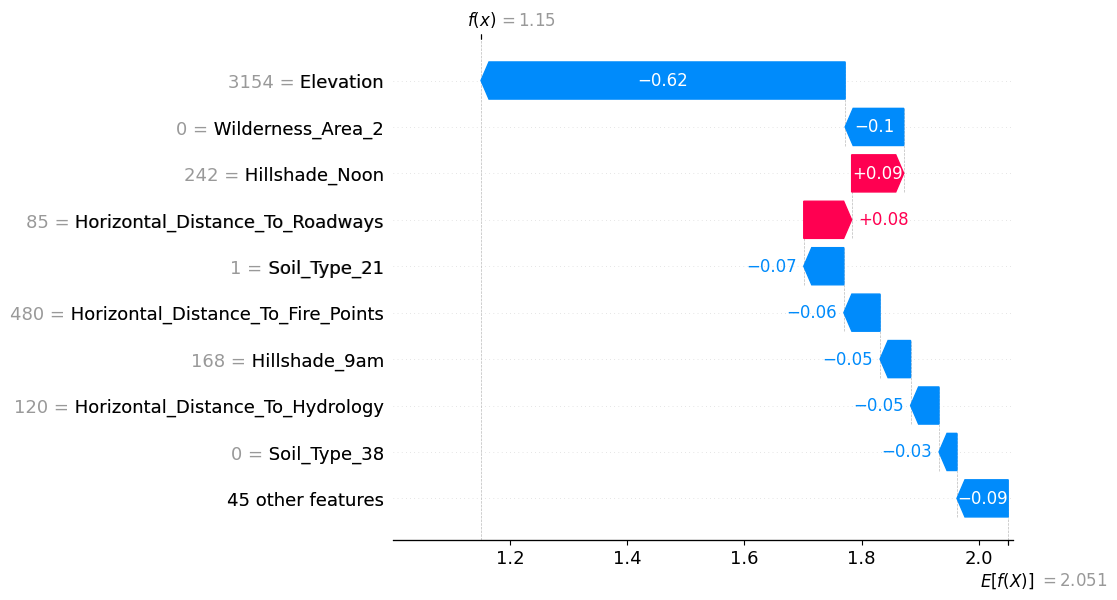

In [5]:
import shap
import time
import numpy as np
import matplotlib.pyplot as plt

N_BACKGROUND = 100   # background samples for KernelSHAP reference distribution
N_EVAL = 20          # number of samples to explain

for config, model in zip(all_combi_configs, all_trained_models):
    data = config.dataset.load_dataset()
    X = data["X"]
    feature_names = list(data["feature_names"])

    X_background = shap.sample(X, N_BACKGROUND, random_state=42)
    X_eval = X.iloc[N_BACKGROUND : N_BACKGROUND + N_EVAL]

    print(f"\n=== {data['name']} | {config.model.value} ===")

    # --- KernelSHAP (approximation, model-agnostic) ---
    print("  KernelSHAP ...")
    start = time.time()
    kernel_explainer = shap.KernelExplainer(model.predict, X_background)
    kernel_values = kernel_explainer.shap_values(X_eval, silent=True)
    kernel_duration = time.time() - start

    # --- TreeSHAP (true value, tree-specific) ---
    print("  TreeSHAP (true value) ...")
    start = time.time()
    explainer = shap.Explainer(model)
    shap_values = explainer(X_eval)
    tree_duration = time.time() - start

    print(f"  KernelSHAP: {kernel_duration:.3f}s | TreeSHAP: {tree_duration:.3f}s | Speedup: {kernel_duration / tree_duration:.1f}x")

    # --- Runtime comparison bar chart ---
    fig, ax = plt.subplots(figsize=(5, 3))
    methods = ["KernelSHAP\n(approx)", "TreeSHAP\n(true value)"]
    durations = [kernel_duration, tree_duration]
    bars = ax.bar(methods, durations, color=["#3498db", "#e74c3c"], width=0.4)
    for bar, dur in zip(bars, durations):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(durations) * 0.02,
            f"{dur:.3f}s",
            ha="center", va="bottom", fontsize=10,
        )
    ax.set_ylabel("Wall-clock time (s)")
    ax.set_title(f"Runtime – {data['name']} | {config.model.value}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # --- KernelSHAP waterfall (sample 0) ---
    kernel_exp_0 = shap.Explanation(
        values=kernel_values[0],
        base_values=float(kernel_explainer.expected_value),
        data=X_eval.iloc[0].values,
        feature_names=feature_names,
    )
    print(f"  KernelSHAP waterfall – {data['name']} (sample 0):")
    shap.plots.waterfall(kernel_exp_0)

    # --- TreeSHAP waterfall (sample 0) ---
    print(f"  TreeSHAP waterfall – {data['name']} (sample 0):")
    shap.plots.waterfall(shap_values[0])